# 电子源、轨迹与 Geant4 水滴输运

## tl;dr
对同一束流比较无材料轨迹和水滴输运，检查成像几何以及进入液滴后的探测分布。

## Context & Methods

几何尺寸、束腰、能散与发散角来自示例配置；水滴中的能损和散射采用 Geant4 `G4EmStandardPhysics_option4`。此 notebook 采用少量电子作可重跑的功能演示，不用于估计最终检出限。

In [1]:
# 所有 Notebook 都从项目根目录读取配置和写入 results/。
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# 不要求先 pip install；优先直接导入当前工作树中的源码。
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
# 两组只改变输运引擎：ray 无材料散射，Geant4 计算水中相互作用。
from droplet_shadow import load_config, simulate
from droplet_shadow.simulation import compare_result
ray = load_config(ROOT / 'examples/baseline-ray.yaml').with_updates(run={'n_simulated': 600, 'exposure_electrons': 600})
water = load_config(ROOT / 'examples/baseline-geant4.yaml').with_updates(run={'n_simulated': 600, 'exposure_electrons': 600})
reference = simulate(ray, ROOT / 'results/notebook_ray')
transport = simulate(water, ROOT / 'results/notebook_geant4')
print('M=',water.geometry.magnification, 'water hits=',len(transport.hits['x_m']), 'entered fraction=',transport.metrics['entered_detector_fraction'])

M= 51.0 water hits= 595 entered fraction= 0.095


## Results

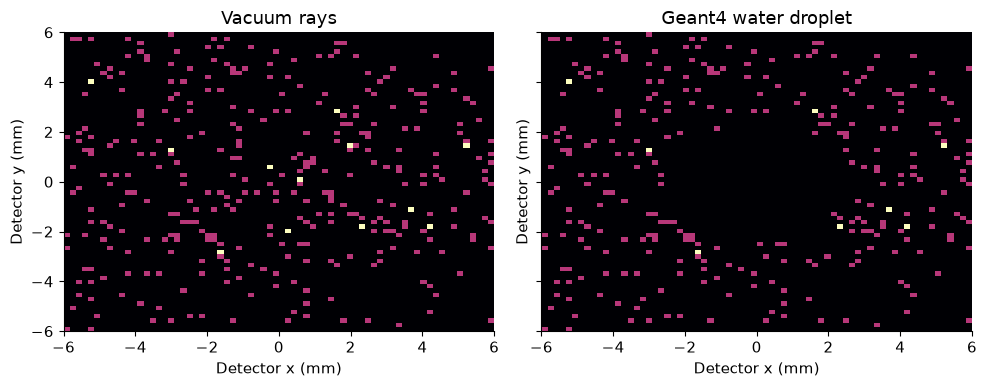

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, result, title in zip(axes, [reference, transport], ['Vacuum rays', 'Geant4 water droplet']):
    ax.hist2d(result.hits['x_m'] * 1e3, result.hits['y_m'] * 1e3, bins=70, range=[[-6,6],[-6,6]], cmap='magma')
    ax.set(xlabel='Detector x (mm)', ylabel='Detector y (mm)', title=title)
fig.tight_layout(); plt.show()

## 实现追溯

电子源协方差与相对论动量在 [`source.py`](../src/droplet_shadow/source.py)，无材料轨迹在 [`rays.py`](../src/droplet_shadow/rays.py)，Python/Geant4 单位转换与 CSV 接口在 [`native.py`](../src/droplet_shadow/native.py)，Geant4 物理、步长和记录逻辑在 [`cpp/main.cpp`](../cpp/main.cpp)。详细中间量见第 5 个 Notebook。

## Takeaways

水滴材料会改变透射电子及次级电子的分布。不同物理机制的定量区分需采用相同源、曝光和探测器设置的参考计算。